# Figs. 6, S6B

In [1]:
import sys; sys.path.append('..') ## proejct root
from methods.config import *
import methods.shared as shared
import methods.plot_utils as plot_utils

import pickle

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats
import seaborn as sns

rnd = np.random.default_rng()
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['svg.fonttype'] = 'none'


## Fig. 6B: Co-housed community lineage trajectories

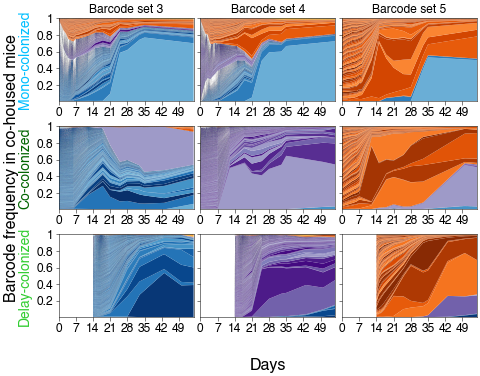

In [ ]:
## this cell takes a few minutes, to plot ~thousands of lineages

expt = 'E2'
fig = plt.figure(figsize=(7.5, 5.5))
gs = plt.GridSpec(nrows=5, ncols=3, figure=fig, height_ratios=(1, 0.3, 1, 0.3, 1), hspace=0.0, wspace=0.05)
outer_ax = fig.add_subplot(gs[:, :])
outer_ax.set_xlabel('Days', fontsize=16, labelpad=40)
outer_ax.set_ylabel('Barcode frequency in co-housed mice', fontsize=16, labelpad=40)
plot_utils.turn_off_ax(outer_ax)

MAX_CUTOFF = 1e-5
FINAL_CUTOFF = 1
for row, (m_set, condition_color, label) in enumerate(zip([[8, 9, 10], [3, 4, 5], [13, 14, 15]],
                                                   ['deepskyblue', 'darkgreen', 'limegreen'], ['Mono-colonized', 'Co-colonized', 'Delay-colonized'])):
    large_indices = shared.find_large_barcodes(expt, m_set, max_cutoff=MAX_CUTOFF, final_cutoff=FINAL_CUTOFF)
    ordered_indices, ordered_colors = shared.order_barcodes_by_pool(large_indices, shared.barcode_pool_assignments, [('S3', 'Blues'), ('S4', 'Purples'), ('S5', 'Oranges'), ('S1', 'Wistia'), ('S2', 'Wistia'), ('E2_shared', 'Greys'), ('E2_ambiguous', 'Greys')], cg_at_end=False)
    for col, mouse in enumerate(m_set):
        days, reads, depths = shared.get_mouse_timecourse(expt, mouse, min_depth=10**3)
        days, freqs = shared.make_muller_freqs(expt, mouse, ordered_indices, 18, 
                                               include_reseq=True, include_pseudo_derepped=True, min_depth=10**4)
        if mouse > 10:
            freqs = freqs[days >= 14]
            days = days[days >= 14]

        ax = fig.add_subplot(gs[row*2, col])
        shared.muller_plot(ax, days, ordered_indices, freqs, ordered_colors)

        ax.set_xlim(0, 55)
        ax.set_xticks([0, 7, 14, 21, 28, 35, 42, 49])
        ax.set_xticklabels([0, 7, 14, 21, 28, 35, 42, 49], fontsize=12)

        ax.set_ylim(0, 1)
        ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1])
        ax.set_yticklabels([0.2, 0.4, 0.6, 0.8, 1], fontsize=12)

        ax.spines['top'].set_linewidth(0.5)
        ax.spines['right'].set_linewidth(0.5)
        ax.spines['bottom'].set_linewidth(0.5)
        ax.spines['left'].set_linewidth(0.5)
        ax.tick_params(axis='x', direction='out', width=0.5)
        ax.tick_params(axis='y', direction='out', width=0.5)

        if row == 0:
            ax.set_title(f'Barcode set {col+3}', fontsize=12)
        if col > 0:
            ax.set_yticklabels([])
        if col == 0:
            ax.set_ylabel(label, fontsize=14, color=condition_color, ha='center')

fig.savefig(f'{figures_dir}/fig6B_comm_cohoused_muller.svg', transparent=True, bbox_inches='tight', dpi=500)
fig.savefig(f'{figures_dir}/fig6B_comm_cohoused_muller.pdf', transparent=True, bbox_inches='tight', dpi=500)


## Figs. 6D, S6B: Transmission-rate estimates

In [4]:
expt = 'E2'
max_dt = 3
max_day = 60

cohoused_mice_dict = {8: [9, 10], 9: [8, 10], 10: [8, 9], 
                      3: [4, 5], 4: [3, 5], 5: [3, 4], 
                      13: [14, 15], 14: [13, 15], 15: [13, 14]}

reseq_large_indices = np.argsort(np.sum(shared.reseq_array, axis=0))[::-1][:1000]
reseq_large_bool = np.full(shared.reseq_array.shape[1], False)
reseq_large_bool[reseq_large_indices] = True


S3_bool = shared.barcode_pool_assignments['S3'][1] * (~reseq_large_bool)
S4_bool = shared.barcode_pool_assignments['S4'][1] * (~reseq_large_bool)
S5_bool = shared.barcode_pool_assignments['S5'][1] * (~reseq_large_bool)

cohoused_mice_bool = {8:S3_bool, 9:S4_bool, 10:S5_bool, 3:S3_bool, 4:S4_bool, 5:S5_bool, 13:S3_bool, 14:S4_bool, 15:S5_bool}


E2_transmission_dict = {m:{donor:{} for donor in donors} for m, donors in cohoused_mice_dict.items()}

rescale_migration = 3
max_groups = 2
min_barcodes = 10
detect_threshold= 0.5
for recipient_mouse, donor_mice in cohoused_mice_dict.items():
    for donor_mouse in donor_mice:
        time_pts = shared.find_consecutive_timepoints(expt, [donor_mouse], recipient_mouse, max_dt=max_dt, max_day=max_day)
        for i, time_pt in enumerate(time_pts):
            t0, t1 = time_pt
            output_dict = shared.measure_transmission_in_interval(expt, recipient_mouse, [donor_mouse], t0, t1, 
                                                                pool_assignment_bool=cohoused_mice_bool[donor_mouse], coarse_grain_num_groups=max_groups, 
                                                                min_barcodes=min_barcodes, rescale_migration=rescale_migration, detect_threshold=detect_threshold)
            E2_transmission_dict[recipient_mouse][donor_mouse][(t0, t1)] = output_dict

# Load E1 transmission estimates for comparison.
with open(f'{pickled_dir}/E1_transmission_dict.pkl', 'rb') as f:
    E1_transmission_dict = pickle.load(f)


Not enough barcodes for 8 at 33 to 35
Not enough barcodes for 8 at 15 to 18
Not enough barcodes for 8 at 18 to 21
Not enough barcodes for 8 at 25 to 28
Not enough barcodes for 8 at 33 to 35
Not enough barcodes for 9 at 15 to 18
Not enough barcodes for 9 at 18 to 21
Not enough barcodes for 9 at 25 to 28
Not enough barcodes for 9 at 33 to 35
no detected barcodes, m= 0.0015599306468096672
no detected barcodes, m= 0.00017780707530844618
no detected barcodes, m= 0.10091537623310688
Not enough barcodes for 3 at 15 to 18
Not enough barcodes for 3 at 18 to 21
Not enough barcodes for 3 at 25 to 28
Not enough barcodes for 3 at 33 to 35
Not enough barcodes for 4 at 18 to 21
Not enough barcodes for 4 at 25 to 28
Not enough barcodes for 4 at 33 to 35
no detected barcodes, m= 0.00033236925561631127
no detected barcodes, m= 0.0025063177619497096
no detected barcodes, m= 0.00031475797042189414
no detected barcodes, m= 0.00035112055081881164
no detected barcodes, m= 0.0020172320226750605
Not enough bar

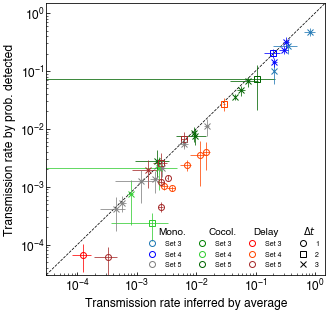

In [ ]:
si_fig, si_ax = plt.subplots(figsize=(5, 5))
mouse_colors = {8:'tab:blue', 9:'blue', 10:'grey', 3:'green', 4:'limegreen', 5:'darkgreen', 13:'red', 14:'orangered', 15:'brown'}
E2_transmission_avg = {m:[] for m in mouse_colors.keys()}
for r, recipient_m in enumerate([3,4,5,13,14,15,8,9,10]):
    for donor in E2_transmission_dict[recipient_m].keys():
        transmission_measurements = E2_transmission_dict[recipient_m][donor]
        color = mouse_colors[recipient_m]


        for (t0, t1), measurements in transmission_measurements.items():
            if measurements is None:
                continue
            if t1-t0 > 3: continue
            elif t1-t0 == 2 and (t0+1, t1) in transmission_measurements: continue
            elif t1-t0 == 3 and np.any([(t0 + x, t1) in transmission_measurements for x in range(1,3)]): continue
            
            if t1-t0 == 1: fmt = 'o'
            elif t1-t0 == 2: fmt = 's'
            elif t1-t0 == 3: fmt = 'x'
        
            
            donor_floor, recip_floor_t0, recip_floor_t1 = measurements['freq floors']
            m_detect, m_detect_err  = measurements['detected inference']
            (donor_valid, recip_valid, donor_cg, recip_cg) = measurements['ratio raw data'] 
            bins, density, errs, num_barcodes_per_bin = measurements['detected raw data']
            m_ratio, m_ratio_err = measurements['ratio inference']

            E2_transmission_avg[recipient_m].append(m_detect)

            if np.sum(recip_cg) < recip_floor_t1:
                continue

            dt = 1
            si_ax.errorbar(m_ratio/dt, m_detect/dt, xerr=m_ratio_err/dt, yerr=m_detect_err/dt, color=mouse_colors[recipient_m], mfc='none', fmt=fmt)


legend_markers = [mpl.lines.Line2D([0], [0], marker='o', color=mouse_colors[mouse], markerfacecolor='none', lw=0) for mouse in [8,9,10, 3,4,5,13,14,15]] + \
                [mpl.lines.Line2D([0], [0], marker='o', mfc='none', color='black',lw=0, ),
                  mpl.lines.Line2D([0], [0], marker='s', mfc='none', color='black',lw=0 ),
                  mpl.lines.Line2D([0], [0], marker='x', mfc='none', color='black',lw=0 )]
si_ax.legend(legend_markers, ['Set 3', 'Set 4', 'Set 5', 'Set 3', 'Set 4', 'Set 5', 'Set 3', 'Set 4', 'Set 5', '1', '2', '3'], loc=4, ncol=4, fontsize=7, frameon=False)
si_ax.text(0.4, 0.15, 'Mono.', transform=si_ax.transAxes, ha='left', color='black')
si_ax.text(0.58, 0.15, 'Cocol.', transform=si_ax.transAxes, ha='left', color='black')
si_ax.text(0.74, 0.15, 'Delay', transform=si_ax.transAxes, ha='left', color='black')
si_ax.text(0.92, 0.15, '$\Delta t$', transform=si_ax.transAxes, ha='left', color='black')

plot_utils.plot_diagonal(si_ax)
si_ax.set_xscale('log')
si_ax.set_yscale('log')
si_ax.set_xlabel('Transmission rate inferred by average', fontsize=12)
si_ax.set_ylabel('Transmission rate by prob. detected', fontsize=12)
si_ax.tick_params(axis='y', labelsize=12)
si_ax.tick_params(axis='x', labelsize=12)
si_ax.set_xlim(3*10**-5, 1.5)
si_ax.set_ylim(3*10**-5, 1.5)

si_fig.savefig(f'{figures_dir}/figS6B_comm_transmission.svg', format='svg', transparent=True, bbox_inches='tight')
si_fig.savefig(f'{figures_dir}/figS6B_comm_transmission.pdf', transparent=True, bbox_inches='tight')


In [6]:
mono_m, mono_m_err, mono_m_labels = [], [], []
for mouse, transmission_dict in E1_transmission_dict.items():
    for (t0, t1), measurements in transmission_dict.items():
        if t1<=14 or measurements is None:
                continue
        if t1-t0 > 3: continue
        elif t1-t0 == 2 and (t0+1, t1) in transmission_dict: continue
        elif t1-t0 == 3 and np.any([(t0 + x, t1) in transmission_dict for x in range(1,3)]): continue
        
        donor_floor, recip_floor_t0, recip_floor_t1 = measurements['freq floors']
        valid_donor, valid_recip, donor_cg, recip_cg = measurements['ratio raw data']
        transmission, transmission_err = measurements['detected inference']
        if np.isnan(transmission):
            continue
        dt = 1

        mono_m.append(transmission/dt)
        mono_m_err.append(transmission_err/dt)

        if mouse in [4,5]:
            mono_m_labels.append('P2 col.')
        elif mouse in [6,7]:
            mono_m_labels.append('P1 col.')


comm_m, comm_m_err, comm_m_labels = [], [], []
E2_transmissions = {3:[], 4:[], 5:[], 13:[], 14:[], 15:[], 8:[], 9:[], 10:[]}
for r, recipient_m in enumerate(E2_transmission_dict.keys()):
    for donor in E2_transmission_dict[recipient_m].keys():
        transmission_measurements = E2_transmission_dict[recipient_m][donor]

        for (t0, t1), measurements in transmission_measurements.items():
            if t1 <= 14 or measurements is None:
                continue
            if t1-t0 > 3: continue
            elif t1-t0 == 2 and (t0+1, t1) in transmission_measurements: continue
            elif t1-t0 == 3 and np.any([(t0 + x, t1) in transmission_measurements for x in range(1,3)]): continue
            
            donor_floor, recip_floor_t0, recip_floor_t1 = measurements['freq floors']
            valid_donor, valid_recip, donor_cg, recip_cg = measurements['ratio raw data']
            transmission, transmission_err = measurements['detected inference']
            if np.isnan(transmission):
                continue
            dt = 1

            if recipient_m in [8, 9, 10]:
                mono_m.append(transmission/dt)
                mono_m_err.append(transmission_err/dt)
                if recipient_m == 10:
                    mono_m_labels.append('Set 5 col.')
                else:
                    mono_m_labels.append('Set 3,4 col.')
                
            elif recipient_m in [3,4,5]:
                comm_m.append(transmission/dt)
                comm_m_err.append(transmission_err/dt)
                comm_m_labels.append('Co-colonized')

            elif recipient_m in [13,14,15]:
                comm_m.append(transmission/dt)
                comm_m_err.append(transmission_err/dt)
                comm_m_labels.append('Delay-colonized')

log_mono_m = np.log10(mono_m)
log_mono_m_err = np.log10(mono_m_err)
log_comm_m = np.log10(comm_m)
log_comm_m_err = np.log10(comm_m_err)
delta_log_transmission = np.mean(log_mono_m[~np.isnan(log_mono_m)]) - np.mean(log_comm_m[~np.isnan(log_comm_m)])
ttest = scipy.stats.ttest_ind(log_mono_m[~np.isnan(log_mono_m)], log_comm_m[~np.isnan(log_comm_m)], equal_var=False, alternative='greater')
pval = ttest[1]
print(pval)

0.0008436227263891423


/var/folders/x3/8f6xdlhn4hscmskkzs52dycc0000gn/T/ipykernel_35612/3949830961.py:65: RuntimeWarning: divide by zero encountered in log10
  log_mono_m_err = np.log10(mono_m_err)
/var/folders/x3/8f6xdlhn4hscmskkzs52dycc0000gn/T/ipykernel_35612/3949830961.py:67: RuntimeWarning: divide by zero encountered in log10
  log_comm_m_err = np.log10(comm_m_err)


## Fig. 6D: summary of per-interval transmission measures

/var/folders/x3/8f6xdlhn4hscmskkzs52dycc0000gn/T/ipykernel_35612/1003455309.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Monocolonized\n'+r'$\tau_{m}$', 'Community colonized\n'+r'$\tau_{c}$'], fontsize=10)


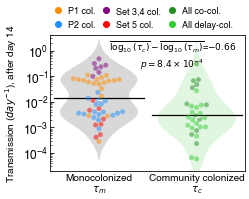

In [ ]:
all_labels = ['Monocolonized']*len(mono_m) + ['Community colonized']*len(comm_m) 
all_transmissions = mono_m + comm_m
all_errs = mono_m_err + comm_m_err
all_sublabels = mono_m_labels + comm_m_labels
df = pd.DataFrame({'Transmission rate':all_transmissions, 'Condition':all_labels, 'Error':all_errs, 'Subcondition':all_sublabels})

color_scheme = {'P1 col.': 'darkorange', 'P2 col.': 'dodgerblue', 'Set 3,4 col.': 'purple', 'Set 5 col.':'red', 'Co-colonized': 'forestgreen', 'Delay-colonized': 'limegreen'}

comm_typical_migration = np.exp(np.mean(np.log(comm_m)))

summary_fig, ax = plt.subplots(figsize=(3.5, 2.5))
sns.violinplot(data=df, x="Condition", y='Transmission rate', hue='Condition',log_scale=True, palette={'Monocolonized': 'grey', 'Community colonized': 'lightgreen'}, ax=ax, alpha=0.3, edgecolor='none', zorder=0)
sns.swarmplot(data=df, x="Condition", y='Transmission rate', hue='Subcondition', palette=color_scheme,  log_scale=True, ax=ax, alpha=0.5, legend=False, zorder=1)

ax.set_xticklabels(['Monocolonized\n'+r'$\tau_{m}$', 'Community colonized\n'+r'$\tau_{c}$'], fontsize=10)
ax.set_xlabel('')
ax.set_ylabel(r'Transmission ($day^{-1}$), after day 14', fontsize=10)
ax.tick_params(axis='x', width=0)


ax.text(0.75, 3, r'$\overline{\log_{10}(\tau_{c})}-\overline{\log_{10}(\tau_{m})}$'+ f'=$-{delta_log_transmission:.2f}$'+f'\n$p={plot_utils.as_si(pval,1)}$', color='k', ha='center', va='top', fontsize=9)
ax.set_ylim(2*10**-5, 4)


ax.axhline(10**np.nanmean(np.log10(mono_m)), xmin=0.02, xmax=0.48, lw=1.25, color='black', zorder=0)
ax.axhline(10**np.nanmean(np.log10(comm_m)), xmin=0.52, xmax=0.98, lw=1.25, color='black', zorder=0)
legend_markers = [mpl.lines.Line2D([0], [0], marker='o', color=color, lw=0) for color in ['darkorange', 'dodgerblue', 'purple', 'red', 'forestgreen', 'limegreen']]
legend_labels = ['P1 col.', 'P2 col.', 'Set 3,4 col.', 'Set 5 col.', 'All co-col.', 'All delay-col.']
ax.legend(legend_markers, legend_labels, frameon=False, ncol=3, bbox_transform=ax.transAxes, fontsize=9, handletextpad=0.1, columnspacing=0.2, loc=(-0.025, 1.02))

summary_fig.savefig(f'{figures_dir}/fig6D_summary_of_transmission.pdf', transparent=True, bbox_inches='tight')
summary_fig.savefig(f'{figures_dir}/fig6D_summary_of_transmission.svg', transparent=True, bbox_inches='tight')


## Fig. 6C: Early frequency convergence

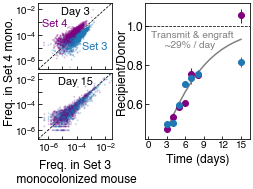

In [ ]:
donor_m_colors = {8:'tab:blue', 9:'purple'}
DAY0_MIN = 10**-4
SHARED_DAYS = np.array( [day for day in range(3,16) if ('E2', 8, day) in shared.library_array_map
               and ('E2', 9, day) in shared.library_array_map] )
day_freq_map = {day:([], [], []) for day in SHARED_DAYS}

fig = plt.figure(figsize=(3.8, 2.5))
gs = plt.GridSpec(nrows=1, ncols=3, width_ratios=(0.7,0.25,1), wspace=0.05, figure=fig)
outer_scatter = fig.add_subplot(gs[:1])
plot_utils.turn_off_ax(outer_scatter)
outer_scatter.set_xlabel('Freq. in Set 3\n monocolonized mouse', fontsize=12, labelpad=20)
outer_scatter.set_ylabel('Freq. in Set 4 mono.', fontsize=12, labelpad=22)

summary_ax = fig.add_subplot(gs[-1])
fitting_data = [[], [], []]
for recip_m, donor_m, donor_bool in [(8, 9, shared.barcode_pool_assignments['S4'][1]), (9, 8, shared.barcode_pool_assignments['S3'][1])]:
    init_day = SHARED_DAYS[0]
    _, recip_reads, recip_depth = [e for e in shared.get_mouse_timecourse('E2', recip_m, min_depth=10**4, specific_timepoints=[init_day])]
    _, donor_reads, donor_depth = [e for e in shared.get_mouse_timecourse('E2', donor_m, min_depth=10**4, specific_timepoints=[init_day])]

    recip_init = shared.calc_freqs(recip_reads, recip_depth)
    donor_init = shared.calc_freqs(donor_reads, donor_depth)
    init_avg = (recip_init + donor_init) / 2

    donor_init_large = (donor_init > DAY0_MIN)
    valid = donor_bool
    ratios = recip_init[valid & donor_init_large] / init_avg[valid & donor_init_large]
    sorting = ratios.argsort()

    sorted_indices = np.arange(valid.shape[0])[valid][sorting]
    y, yerr = [], []
    subset = sorted_indices
    y, yerr = [], []
    
    for d, day in enumerate(SHARED_DAYS):
        _, recip_reads, recip_De = [e[0] for e in shared.get_mouse_timecourse('E2', recip_m, min_depth=10**4, specific_timepoints=[day])]
        _, donor_reads, donor_De = [e[0] for e in shared.get_mouse_timecourse('E2', donor_m, min_depth=10**4, specific_timepoints=[day])]
        recip_freqs = shared.calc_freqs(recip_reads, recip_De)
        donor_freqs = shared.calc_freqs(donor_reads, donor_De) 

        recip_subset_freqs = recip_freqs[subset]
        donor_subset_freqs = donor_freqs[subset]

        mavg_freqs = donor_subset_freqs
        finite_avg = (recip_subset_freqs > 1/recip_De) * (donor_subset_freqs > 1/donor_De)
        ratios = (recip_subset_freqs[finite_avg] / mavg_freqs[finite_avg])
        
        bootstrap_ratios = []
        for _ in range(1000):
            bootstrap_sample = rnd.choice(np.arange(ratios.shape[0]), ratios.shape[0], replace=True)
            bootstrap_ratios.append( np.median(ratios[bootstrap_sample]) )
        median, iqr = np.median(ratios), np.percentile(bootstrap_ratios, (5, 95))

        if donor_m == 8:
            day_freq_map[day][0].extend(donor_subset_freqs)
            day_freq_map[day][1].extend(recip_subset_freqs)
            day_freq_map[day][2].extend( [donor_m_colors[donor_m]]*len(donor_subset_freqs) )

        elif donor_m == 9:
            day_freq_map[day][1].extend(donor_subset_freqs)
            day_freq_map[day][0].extend(recip_subset_freqs)
            day_freq_map[day][2].extend( [donor_m_colors[donor_m]]*len(donor_subset_freqs) )
            
        err = np.array([median - iqr[0], iqr[1] - median])
        y.append(median) 
        yerr.append(err)

    summary_ax.errorbar(SHARED_DAYS, np.array(y), yerr=np.transpose(yerr), marker='.', markersize=12, lw=0, elinewidth=1, color=donor_m_colors[donor_m])
    
    fitting_data[0].extend(SHARED_DAYS)
    fitting_data[1].extend(y)
    fitting_data[2].extend(yerr)

summary_ax.set_xlim(-0.1, 16)
summary_ax.set_xticks([0, 3, 6, 9, 12, 15])
summary_ax.set_xticklabels([0, 3, 6, 9, 12, 15], fontsize=10)
summary_ax.set_xlabel("Time (days)", fontsize=12)
summary_ax.set_ylabel("Recipient/Donor", fontsize=12, labelpad=-2)
summary_ax.set_ylim(0.42, 1.12)
summary_ax.set_xlim(-0.5, 16.5)
summary_ax.axhline(1, color='black', linestyle='dashed', zorder=0)

if 'theory':
    days_before_8, y, y_err = fitting_data
    x = np.array([[3]*len(days_before_8), days_before_8])

    def theory_recip_donor_ratio(x, rescaled_migration, init_ratio):
        init_day, day = x
        
        rho_num = 1 - (1-init_ratio)/(1+init_ratio) * np.exp(-rescaled_migration*(day-init_day))
        rho_denom = 1 + (1-init_ratio)/(1+init_ratio) * np.exp(-rescaled_migration*(day-init_day))
        return rho_num / rho_denom
    popt, pcov = scipy.optimize.curve_fit(theory_recip_donor_ratio, x, y, p0=(0.5, 0.4))
    fitted_rescaled_tau, _ = popt[0], popt[1]
    fitted_tau = fitted_rescaled_tau / (2/3) #2/3 is to rescale inference to input transmission per day
    days = np.arange(3, 16)
    y_fit = theory_recip_donor_ratio([3, days], *popt)
    summary_ax.plot(days, y_fit, color='grey', lw=1.5)
    summary_ax.text(0.5, 0.98, f'Transmit & engraft\n     ~{int(fitted_tau*100)}% / day', color='grey', fontsize=10, ha='left', va='top')

example_day_gs = mpl.gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[0], hspace=0.05)
for d, day in enumerate([3,15]):
    x, y, colors = [np.array(e) for e in day_freq_map[day]]
    perm = rnd.permutation(np.arange(len(x)))

    ax = fig.add_subplot(example_day_gs[d])
    ax.scatter(x[perm], y[perm], s=1, alpha=0.2, color=colors[perm], rasterized=True)
    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.set_xlim(2*10**-7, 3*10**-2)
    ax.set_ylim(2*10**-7, 3*10**-2)
    ax.text(0.5, 0.95, f'Day {day}', transform=ax.transAxes, fontsize=11, ha='center', va='top')
    xticks = [10**-6, 10**-5, 10**-4, 10**-3, 10**-2]
    ax.set_xticks(xticks)
    ax.set_yticks(xticks)
    labels = np.array(ax.get_xticklabels())
    labels[1::2] = ''
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    
    if d == 0:
        legend_markers = [mpl.lines.Line2D([0], [0], marker='o', color='tab:blue', lw=0),
                          mpl.lines.Line2D([0], [0], marker='o', color='purple', lw=0)]
        ax.text(0.6, 0.3, "Set 3", color=donor_m_colors[8], transform=ax.transAxes, fontsize=11, ha='left')
        ax.text(0.4, 0.65, "Set 4", color=donor_m_colors[9], transform=ax.transAxes, fontsize=11, ha='right')
        ax.set_xticklabels([])
    
    plot_utils.plot_diagonal(ax)
    ax.tick_params(axis='both', labelsize=10)

fig.savefig(f'{figures_dir}/fig6C_M89_transmission_ratio.pdf', transparent=True, bbox_inches='tight')
fig.savefig(f'{figures_dir}/fig6C_M89_transmission_ratio.svg', transparent=True, bbox_inches='tight')


## Figs. 6E–J: Transmission and engraftment examples

1
1
1
1
1
1
1
1
1
1
1
1


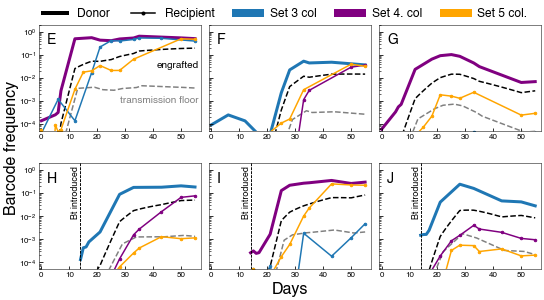

In [ ]:
expt = 'E2'

example_barcodes = {
    'ATTTGTTAGGGCAACAGTGC': ([4], 'navy', 0, 0, 'E'),
    'ATTTACTGGCGATAAACATA':([3], 'darkorange', 0, 1, 'F'),
    'AATCTGTAAACCCTCTATTG': ([4], 'navy', 0, 2, 'G'),
    'CGGCCGTGAGTGAATCCTGT': ([13], 'navy', 1, 0, 'H'),
    'TTTTGGCGTATAGTGACCAT': ([14], 'darkorange', 1, 1, 'I'),
    'ATACATAGGCAGCATCTCAC': ([13], 'darkorange', 1, 2, 'J'),
    }


donor_recipient_map = {3:[4,5], 4:[3,5], 5:[3,4], 13:[14,15], 14:[13,15], 15:[13,14]}
mouse_colors = {3:'tab:blue', 4:'purple', 5:'orange',
                13:'tab:blue', 14:'purple', 15:'orange'}

fig = plt.figure(figsize=(9,4.5))
gs = plt.GridSpec(2,3, figure=fig, wspace=0.05, hspace=0.3)
outer_upper = fig.add_subplot(gs[:, :])
outer_lower = fig.add_subplot(gs[-1, :])
plot_utils.turn_off_ax(outer_upper)
plot_utils.turn_off_ax(outer_lower)
outer_lower.set_xlabel('Days', fontsize=16, labelpad=12)
outer_upper.set_ylabel('Barcode frequency', labelpad=20, fontsize=16)

transmission_averages = {m:np.mean(10**log_comm_m)for m in [3,4,5,13,14,15]}

for barcode, (donors, color, row, col, panel) in example_barcodes.items():
    bc_index = np.where(shared.barcodes == barcode)[0][0]
    donor_mouse = donors[0]
    recipients = donor_recipient_map[donors[0]]
    freq_ax = fig.add_subplot(gs[row, col])

    init_day = 0
    if donor_mouse > 10:
        init_day = 14

    shared.plot_barcode_trajectories(freq_ax, barcode, 'E2', donors, recipients, transmission_averages, mouse_colors, init_day, plot_other_donors=False)

    freq_ax.set_yscale('log')
    freq_ax.set_yticks([10**-4, 10**-3, 10**-2, 10**-1, 1])
    freq_ax.set_ylim(5*10**-5, 2)
    freq_ax.set_xticks([0, 10, 20, 30, 40,50])
    freq_ax.set_xticklabels([0, 10, 20, 30, 40,50], fontsize=8)
    freq_ax.yaxis.set_tick_params(labelsize=8)

    freq_ax.text(0.05, 0.82, panel, transform=freq_ax.transAxes, fontsize=14, weight='heavy')
    if row == 0 and col == 0:
        freq_ax.text(0.99, 0.33, 'transmission floor', fontsize=10, color='grey',
                     ha='right', va='top', transform=freq_ax.transAxes)
        freq_ax.text(0.99, 0.66, 'engrafted', fontsize=10, color='black',
                     ha='right', va='top', transform=freq_ax.transAxes)


    if row == 1:
        freq_ax.axvline(14, color='black', linestyle='dashed')
    if col!=0:
        freq_ax.set_yticklabels([])
    freq_ax.set_xlim(-1, 57)

    for spine in ['top', 'right', 'left', 'bottom']:
        freq_ax.spines[spine].set_linewidth(0.5)

    if donor_mouse > 10:
        freq_ax.axvline(14, color='black', linestyle='dashed', zorder=0)
        freq_ax.text(14, 1.5, 'Bt introduced', rotation=90, fontsize=9, va='top', ha='right')



legend_markers = [mpl.lines.Line2D((0,0), (0,0), lw=4, color='black'), mpl.lines.Line2D((0,0), (0,0), lw=1.5, marker='.', color='black')] +\
                   [mpl.lines.Line2D([0], [0], color=c, lw=8) for c in ['tab:blue', 'purple', 'orange']] 

outer_upper.legend(legend_markers, ['Donor', 'Recipient', 'Set 3 col', 'Set 4. col', 'Set 5 col.'], 
          ncol=5, columnspacing=1.8, labelspacing=0.25, fontsize=12, frameon=False, loc=(0, 1.0), bbox_transform=outer_upper.transAxes)

fig.savefig(f'{figures_dir}/fig6E-J_comm_transmission_examples.pdf', transparent=True, bbox_inches='tight')
fig.savefig(f'{figures_dir}/fig6E-J_comm_transmission_examples.svg', transparent=True, bbox_inches='tight')
